# Download PCB dataset

In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# zip_file_path = '/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/My Drive/Colab Notebooks/PCB-archive.zip'
# Update this path to your local PCB-archive.zip location
zip_file_path = '/content/drive/MyDrive/PCB-archive.zip'
extracted_folder_path = '/content/drive/MyDrive/hripcb_dataset'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_folder_path)

print(f'ZIP file successfully extracted to "{extracted_folder_path}" directory.')


Check items under PCB data/PCB_DATASET (verify extraction is correct)

In [8]:
import os
directory_path = '/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET'
file_list = os.listdir(directory_path)

print("Files in directory:")
for file_name in file_list:
    print(file_name)

Files in directory:
Annotations
PCB_USED
images
rotation
rotate.py
train
val
test
resized_images


# Data Preprocessing



Check JPG quantities

In [9]:
import os

base_path = '/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/images'
folders = ['Spurious_copper', 'Mouse_bite', 'Open_circuit', 'Missing_hole', 'Spur', 'Short']

for folder in folders:
    folder_path = os.path.join(base_path, folder)
    jpg_count = len([f for f in os.listdir(folder_path) if f.endswith('.jpg')])
    print(f"{folder}: {jpg_count} JPG files")

Spurious_copper: 116 JPG files
Mouse_bite: 115 JPG files
Open_circuit: 116 JPG files
Missing_hole: 115 JPG files
Spur: 115 JPG files
Short: 116 JPG files


Check XML quantities

In [10]:
import os
xml_folder_path = "/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/Annotations/"

xml_files = []
for folder in ['Spurious_copper', 'Mouse_bite', 'Open_circuit', 'Missing_hole', 'Spur', 'Short']:
    folder_path = os.path.join(xml_folder_path, folder)
    if os.path.isdir(folder_path):
        xml_files.extend([os.path.join(folder, f) for f in os.listdir(folder_path) if f.endswith('.xml')])

num_files = len(xml_files)
print(f"Total of {num_files} XML files")

for folder in ['Spurious_copper', 'Mouse_bite', 'Open_circuit', 'Missing_hole', 'Spur', 'Short']:
    folder_path = os.path.join(xml_folder_path, folder)
    num_files_in_folder = len([f for f in os.listdir(folder_path) if f.endswith('.xml')])
    print(f"{folder} folder contains {num_files_in_folder} XML files")

Total of 693 XML files
Spurious_copper folder contains 116 XML files
Mouse_bite folder contains 115 XML files
Open_circuit folder contains 116 XML files
Missing_hole folder contains 115 XML files
Spur folder contains 115 XML files
Short folder contains 116 XML files


In [12]:
!pip install Pillow

from PIL import Image
import os

original_folder = '/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/images'
resized_folder = '/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/resized_images'
os.makedirs(resized_folder, exist_ok=True)
folders = ['Spurious_copper', 'Mouse_bite', 'Open_circuit', 'Missing_hole', 'Spur', 'Short']

for folder in folders:
    folder_path = os.path.join(original_folder, folder)
    images = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    os.makedirs(resized_folder, exist_ok=True)
    for image in images:
        image_path = os.path.join(folder_path, image)
        img = Image.open(image_path)
        resized_img = img.resize((640, 640))
        output_path = os.path.join(resized_folder, image)
        resized_img.save(output_path)
        print(f"Processed: {image}, new file saved at: {output_path}")
print("Finished resizing images and saved to new folder.")

Processed: 01_spurious_copper_03.jpg, new file saved at: /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/resized_images/01_spurious_copper_03.jpg
Processed: 01_spurious_copper_09.jpg, new file saved at: /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/resized_images/01_spurious_copper_09.jpg
Processed: 01_spurious_copper_12.jpg, new file saved at: /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/resized_images/01_spurious_copper_12.jpg
Processed: 01_spurious_copper_02.jpg, new file saved at: /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/resized_images/01_spurious_copper_02.jpg
Processed: 01_spurious_copper_07.jpg, new file saved at: /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/resized_images/01_spurious_copper_07.jpg
Processed: 01_spurious_copper_08.jpg, new file saved at: /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/resized_images/01_spurious_copper_08.jpg
Processed: 01_spurious_coppe

In [13]:
import os
import xml.etree.ElementTree as ET
from tqdm import tqdm

def resize_xml(xml_path, output_path, target_size):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    for size in root.iter('size'):
        width = int(size.find('width').text)
        height = int(size.find('height').text)

        size.find('width').text = str(target_size)
        size.find('height').text = str(target_size)

    for obj in root.iter('object'):
        for box in obj.iter('bndbox'):
            xmin = int(box.find('xmin').text)
            ymin = int(box.find('ymin').text)
            xmax = int(box.find('xmax').text)
            ymax = int(box.find('ymax').text)

            xmin = int(xmin * target_size / width)
            ymin = int(ymin * target_size / height)
            xmax = int(xmax * target_size / width)
            ymax = int(ymax * target_size / height)

            box.find('xmin').text = str(xmin)
            box.find('ymin').text = str(ymin)
            box.find('xmax').text = str(xmax)
            box.find('ymax').text = str(ymax)

    tree.write(output_path)

original_annotations_folder = '/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/Annotations'
resized_annotations_folder = '/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/resized_images'
os.makedirs(resized_annotations_folder, exist_ok=True)

target_size = 640
for folder in folders:
    folder_path = os.path.join(original_annotations_folder, folder)

    xml_files = [f for f in os.listdir(folder_path) if f.endswith('.xml')]
    for xml_file in xml_files:
        xml_path = os.path.join(folder_path, xml_file)

        base_filename = os.path.splitext(xml_file)[0]
        output_xml_path = os.path.join(resized_annotations_folder, f"{base_filename}.xml")
        resize_xml(xml_path, output_xml_path, target_size)

        print(f"Processed: {xml_file}, new file saved at: {output_xml_path}")

print("Finished resizing XML files and saved to new folder.")


Processed: 07_spurious_copper_07.xml, new file saved at: /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/resized_images/07_spurious_copper_07.xml
Processed: 06_spurious_copper_01.xml, new file saved at: /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/resized_images/06_spurious_copper_01.xml
Processed: 08_spurious_copper_05.xml, new file saved at: /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/resized_images/08_spurious_copper_05.xml
Processed: 08_spurious_copper_10.xml, new file saved at: /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/resized_images/08_spurious_copper_10.xml
Processed: 01_spurious_copper_02.xml, new file saved at: /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/resized_images/01_spurious_copper_02.xml
Processed: 01_spurious_copper_20.xml, new file saved at: /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/resized_images/01_spurious_copper_20.xml
Processed: 01_spurious_coppe

# Create train, val datasets and labels

In [22]:
import os
import random
from shutil import copyfile

source_folder = '/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/resized_images'

output_folder = '/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET'
os.makedirs(output_folder, exist_ok=True)

train_ratio = 0.8
val_ratio = 0.2

for subset in ['train', 'val']:
    os.makedirs(os.path.join(output_folder, subset, 'images'), exist_ok=True)
    os.makedirs(os.path.join(output_folder, subset, 'labels'), exist_ok=True)

for xml_file in os.listdir(source_folder):
    if xml_file.endswith('.xml'):
        base_filename = os.path.splitext(xml_file)[0]

        rand_num = random.random()
        if rand_num < train_ratio:
            subset_folder = 'train'
        else:
            subset_folder = 'val'

        # Copy XML to labels folder (will be converted to YOLO format later)
        src_xml = os.path.join(source_folder, xml_file)
        dest_xml = os.path.join(output_folder, subset_folder, 'labels', xml_file)
        copyfile(src_xml, dest_xml)

        # Copy JPG to images folder
        jpg_file = f'{base_filename}.jpg'
        src_jpg = os.path.join(source_folder, jpg_file)
        dest_jpg = os.path.join(output_folder, subset_folder, 'images', jpg_file)
        copyfile(src_jpg, dest_jpg)


In [23]:
import os
import xml.etree.ElementTree as ET
from PIL import Image

def convert_xml_to_yolo(xml_path, image_width, image_height, class_mapping):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    labels = []
    for obj in root.findall('object'):
        class_name = obj.find('name').text
        if class_name not in class_mapping:
            continue

        class_id = class_mapping[class_name]
        bbox = obj.find('bndbox')

        x_center = (float(bbox.find('xmin').text) + float(bbox.find('xmax').text)) / 2.0 / image_width
        y_center = (float(bbox.find('ymin').text) + float(bbox.find('ymax').text)) / 2.0 / image_height
        width = (float(bbox.find('xmax').text) - float(bbox.find('xmin').text)) / image_width
        height = (float(bbox.find('ymax').text) - float(bbox.find('ymin').text)) / image_height

        labels.append(f"{class_id} {x_center} {y_center} {width} {height}")

    return labels

def convert_labels_in_folder(images_folder, labels_folder, class_mapping):
    # Convert XML files in labels folder to YOLO format
    for xml_file in os.listdir(labels_folder):
        if xml_file.endswith('.xml'):
            xml_path = os.path.join(labels_folder, xml_file)
            base_filename = os.path.splitext(xml_file)[0]
            
            # Find corresponding image
            image_file = f'{base_filename}.jpg'
            image_path = os.path.join(images_folder, image_file)
            
            if os.path.exists(image_path):
                img = Image.open(image_path)
                image_width, image_height = img.size

                # Convert to YOLO format
                labels = convert_xml_to_yolo(xml_path, image_width, image_height, class_mapping)

                # Save as .txt file
                output_path = os.path.join(labels_folder, f'{base_filename}.txt')
                with open(output_path, 'w') as f:
                    f.write('\n'.join(labels))
                
                # Remove the XML file
                os.remove(xml_path)
                print(f"Converted {xml_file} to {base_filename}.txt")

class_mapping = {'spurious_copper': 0, 'mouse_bite': 1, 'open_circuit': 2, 'missing_hole': 3, 'spur': 4, 'short': 5}    

# Convert labels for train and val sets
convert_labels_in_folder('/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/train/images', '/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/train/labels', class_mapping)
convert_labels_in_folder('/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/val/images', '/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/val/labels', class_mapping)

print("Label conversion complete!")


Converted 07_spurious_copper_07.xml to 07_spurious_copper_07.txt
Converted 06_spurious_copper_01.xml to 06_spurious_copper_01.txt
Converted 08_spurious_copper_05.xml to 08_spurious_copper_05.txt
Converted 08_spurious_copper_10.xml to 08_spurious_copper_10.txt
Converted 01_spurious_copper_02.xml to 01_spurious_copper_02.txt
Converted 01_spurious_copper_20.xml to 01_spurious_copper_20.txt
Converted 01_spurious_copper_12.xml to 01_spurious_copper_12.txt
Converted 11_spurious_copper_10.xml to 11_spurious_copper_10.txt
Converted 09_spurious_copper_05.xml to 09_spurious_copper_05.txt
Converted 05_spurious_copper_08.xml to 05_spurious_copper_08.txt
Converted 09_spurious_copper_08.xml to 09_spurious_copper_08.txt
Converted 04_spurious_copper_07.xml to 04_spurious_copper_07.txt
Converted 09_spurious_copper_02.xml to 09_spurious_copper_02.txt
Converted 04_spurious_copper_13.xml to 04_spurious_copper_13.txt
Converted 09_spurious_copper_09.xml to 09_spurious_copper_09.txt
Converted 08_spurious_cop

Visual inspection

Randomly selected image: 09_short_06.jpg


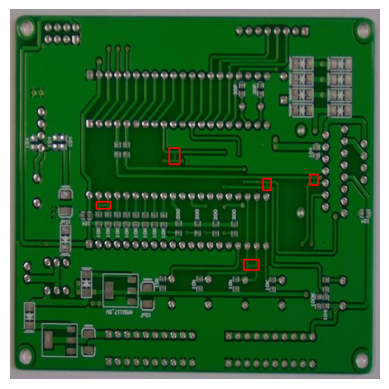

In [24]:
import os
import cv2
import matplotlib.pyplot as plt
import random

def visualize_random_image_with_labels(images_folder, labels_folder):
    image_files = [f for f in os.listdir(images_folder) if f.endswith('.jpg')]

    random_image_file = random.choice(image_files)
    print("Randomly selected image:", random_image_file)

    image_path = os.path.join(images_folder, random_image_file)

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    label_file = os.path.splitext(random_image_file)[0] + '.txt'
    label_path = os.path.join(labels_folder, label_file)

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            class_id = int(parts[0])
            x_center, y_center, width, height = map(float, parts[1:])

            img_height, img_width, _ = image.shape
            x, y, w, h = map(int, [x_center * img_width, y_center * img_height, width * img_width, height * img_height])
            x1, y1, x2, y2 = x - w//2, y - h//2, x + w//2, y + h//2
            cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)

    plt.imshow(image)
    plt.axis('off')
    plt.show()

train_folder = '/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/train/images'
labels_folder = '/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/train/labels'

visualize_random_image_with_labels(train_folder, labels_folder)

# YOLOv5s model

In [2]:
!git clone https://github.com/ultralytics/yolov5  # Clone the YOLOv5 repository
%cd yolov5
!pip install -U -r requirements.txt  # Install dependencies

Cloning into 'yolov5'...
remote: Enumerating objects: 17851, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 17851 (delta 31), reused 15 (delta 8), pack-reused 17799 (from 3)
Receiving objects: 100% (17851/17851), 16.98 MiB | 30.55 MiB/s, done.
Resolving deltas: 100% (12161/12161), done.
/content/yolov5
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 108.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 108.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 121.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64

In [3]:
data_yaml_content = """

train: /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/train/images
val: /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/val/images
nc: 6
names: ['spurious_copper', 'mouse_bite', 'open_circuit', 'missing_hole', 'spur', 'short']
"""

with open('/content/yolov5/data/PCB_data.yaml', 'w') as f:
    f.write(data_yaml_content)

In [ ]:
# Uninstall current PyTorch
!pip uninstall -y torch torchvision

# Install PyTorch with CUDA 12.1 (compatible with Colab)
!pip install torch==2.5.1 torchvision==0.20.1 --index-url https://download.pytorch.org/whl/cu121

# Verify installation
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")

Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: torchvision 0.26.0
Uninstalling torchvision-0.26.0:
  Successfully uninstalled torchvision-0.26.0
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 108.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 87.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 66.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 113.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.5 MB/s eta 0:00:00

# Training with Drive Persistence\n
\n
The following cells:\n
1. Check for existing weights in Google Drive\n
2. Train using those weights (or pretrained yolov5s.pt if none exist)\n
3. Save weights directly to Drive for persistence across sessions

In [9]:
import os
import shutil

# Drive path for saving weights
DRIVE_WEIGHTS_DIR = '/content/drive/MyDrive/pcb_yolov5_weights'
DRIVE_BEST_WEIGHTS = os.path.join(DRIVE_WEIGHTS_DIR, 'best.pt')
DRIVE_LAST_WEIGHTS = os.path.join(DRIVE_WEIGHTS_DIR, 'last.pt')

# Create directory if it doesn't exist
os.makedirs(DRIVE_WEIGHTS_DIR, exist_ok=True)

# Check for existing weights in Drive
if os.path.exists(DRIVE_BEST_WEIGHTS):
    print(f'✓ Found existing best weights in Drive: {DRIVE_BEST_WEIGHTS}')
    print(f'  Size: {os.path.getsize(DRIVE_BEST_WEIGHTS) / (1024*1024):.2f} MB')
    RESUME_WEIGHTS = DRIVE_BEST_WEIGHTS
elif os.path.exists(DRIVE_LAST_WEIGHTS):
    print(f'✓ Found existing last weights in Drive: {DRIVE_LAST_WEIGHTS}')
    print(f'  Size: {os.path.getsize(DRIVE_LAST_WEIGHTS) / (1024*1024):.2f} MB')
    RESUME_WEIGHTS = DRIVE_LAST_WEIGHTS
else:
    print('✗ No existing weights found in Drive. Starting fresh training.')
    RESUME_WEIGHTS = 'yolov5s.pt'  # Use pretrained weights

print(f'\\nWeights to use: {RESUME_WEIGHTS}')
print(f'Weights will be saved to: {DRIVE_WEIGHTS_DIR}')

✗ No existing weights found in Drive. Starting fresh training.
\nWeights to use: yolov5s.pt
Weights will be saved to: /content/drive/MyDrive/pcb_yolov5_weights


In [10]:
# Train with Drive-based project directory
# Weights will be saved directly to Google Drive for persistence
!python train.py --img-size 640 --batch-size 16 --epochs 100 \
    --data /content/yolov5/data/PCB_data.yaml \
    --cfg models/yolov5s.yaml \
    --weights $RESUME_WEIGHTS \
    --name pcb_experiment \
    --save-period 1 \
    --project /content/drive/MyDrive/pcb_yolov5_weights/runs \
    --exist-ok

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-04-08 09:50:50.371699: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775641850.391458    8412 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775641850.397653    8412 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775641850.413187    8412 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775641850.413223    8412 computation_placer.cc:177] computation placer already registere

In [ ]:
# After training, copy best weights to Drive root for easy access
import os
import shutil

# Find the latest experiment folder
import glob
exp_folders = glob.glob('/content/drive/MyDrive/pcb_yolov5_weights/runs/pcb_experiment*')
if exp_folders:
    latest_exp = max(exp_folders, key=os.path.getmtime)
    print(f'Latest experiment: {latest_exp}')
    
    # Copy best.pt and last.pt to the Drive weights root
    src_best = os.path.join(latest_exp, 'weights', 'best.pt')
    src_last = os.path.join(latest_exp, 'weights', 'last.pt')
    
    if os.path.exists(src_best):
        shutil.copy2(src_best, DRIVE_BEST_WEIGHTS)
        print(f'✓ Copied best.pt to {DRIVE_BEST_WEIGHTS}')
    
    if os.path.exists(src_last):
        shutil.copy2(src_last, DRIVE_LAST_WEIGHTS)
        print(f'✓ Copied last.pt to {DRIVE_LAST_WEIGHTS}')
    
    print('\\nWeights saved to Drive! They will persist across sessions.')
else:
    print('No experiment folders found.')

In [32]:
import os
import glob

# Check Drive first, then fall back to local
DRIVE_RUNS_DIR = '/content/drive/MyDrive/pcb_yolov5_weights/runs'
LOCAL_RUNS_DIR = '/content/yolov5/runs'

# List all experiment folders (Drive first)
drive_folders = glob.glob(os.path.join(DRIVE_RUNS_DIR, 'pcb_experiment*'))
local_folders = glob.glob(os.path.join(LOCAL_RUNS_DIR, 'my_experiment*'))

print("=== Experiment Folders in Drive ===")
if drive_folders:
    for folder in sorted(drive_folders):
        print(f"  {folder}")
        results_file = os.path.join(folder, 'results.csv')
        weights_dir = os.path.join(folder, 'weights')
        if os.path.exists(results_file):
            print(f"    ✓ results.csv exists")
        else:
            print(f"    ✗ results.csv NOT found")
        if os.path.exists(os.path.join(weights_dir, 'best.pt')):
            print(f"    ✓ best.pt exists")
else:
    print("  No experiments found in Drive")

print("\n=== Local Experiment Folders ===")
if local_folders:
    for folder in sorted(local_folders):
        print(f"  {folder}")
else:
    print("  No local experiments found")

# Get the latest experiment with results
all_folders = drive_folders + local_folders
valid_folders = [f for f in all_folders if os.path.exists(os.path.join(f, 'results.csv'))]
if valid_folders:
    latest_exp = max(valid_folders, key=os.path.getmtime)
    print(f"\nLatest experiment with results: {latest_exp}")
    RESULTS_CSV = os.path.join(latest_exp, 'results.csv')
    BEST_WEIGHTS = os.path.join(latest_exp, 'weights', 'best.pt')
    print(f"✓ Using: {RESULTS_CSV}")
else:
    print("\n✗ No completed experiments found!")

Available experiment folders:
  /content/yolov5/runs/my_experiment
    ✗ results.csv NOT found (training incomplete)
  /content/yolov5/runs/my_experiment2
    ✗ results.csv NOT found (training incomplete)
  /content/yolov5/runs/my_experiment3
    ✓ results.csv exists

Latest experiment: /content/yolov5/runs/my_experiment3
✓ Using: /content/yolov5/runs/my_experiment3/results.csv


In [35]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# Find the latest experiment folder in Drive
DRIVE_RUNS_DIR = '/content/drive/MyDrive/pcb_yolov5_weights/runs'
exp_folders = glob.glob(os.path.join(DRIVE_RUNS_DIR, 'pcb_experiment*'))

if exp_folders:
    latest_exp = max(exp_folders, key=os.path.getmtime)
    results_path = os.path.join(latest_exp, 'results.csv')
    print(f'Using results from: {results_path}')
else:
    # Fallback to local runs if Drive not available
    local_folders = glob.glob('/content/yolov5/runs/my_experiment*')
    if local_folders:
        latest_exp = max(local_folders, key=os.path.getmtime)
        results_path = os.path.join(latest_exp, 'results.csv')
        print(f'Using local results from: {results_path}')
    else:
        raise FileNotFoundError('No experiment folders found!')

# Load and plot results
df = pd.read_csv(results_path)
df.columns = df.columns.str.strip()

epochs = df['epoch']
train_box_loss = df['train/box_loss']
train_obj_loss = df['train/obj_loss']
train_cls_loss = df['train/cls_loss']
val_box_loss = df['val/box_loss']
val_obj_loss = df['val/obj_loss']
val_cls_loss = df['val/cls_loss']

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Box Loss
axes[0, 0].plot(epochs, train_box_loss, label='Train', color='blue')
axes[0, 0].plot(epochs, val_box_loss, label='Validation', color='orange')
axes[0, 0].set_title('Box Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Object Loss
axes[0, 1].plot(epochs, train_obj_loss, label='Train', color='blue')
axes[0, 1].plot(epochs, val_obj_loss, label='Validation', color='orange')
axes[0, 1].set_title('Object Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Class Loss
axes[1, 0].plot(epochs, train_cls_loss, label='Train', color='blue')
axes[1, 0].plot(epochs, val_cls_loss, label='Validation', color='orange')
axes[1, 0].set_title('Class Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# mAP metrics
if 'metrics/mAP_0.5' in df.columns:
    axes[1, 1].plot(epochs, df['metrics/mAP_0.5'], label='mAP@0.5', color='green')
if 'metrics/mAP_0.5:0.95' in df.columns:
    axes[1, 1].plot(epochs, df['metrics/mAP_0.5:0.95'], label='mAP@0.5:0.95', color='red')
axes[1, 1].set_title('mAP Metrics')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('mAP')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('YOLOv5 Training Metrics - PCB Defect Detection', fontsize=14)
plt.tight_layout()
plt.show()

# Print final metrics
print(f'\n=== Final Epoch Metrics ===')
print(f'Train Box Loss: {train_box_loss.iloc[-1]:.4f}')
print(f'Train Obj Loss: {train_obj_loss.iloc[-1]:.4f}')
print(f'Val Box Loss: {val_box_loss.iloc[-1]:.4f}')
print(f'Val Obj Loss: {val_obj_loss.iloc[-1]:.4f}')
if 'metrics/mAP_0.5' in df.columns:
    print(f'mAP@0.5: {df["metrics/mAP_0.5"].iloc[-1]:.4f}')
if 'metrics/mAP_0.5:0.95' in df.columns:
    print(f'mAP@0.5:0.95: {df["metrics/mAP_0.5:0.95"].iloc[-1]:.4f}')

❌ File not found: /content/yolov5/runs/my_experiment2/results.csv
Training must complete successfully first!
After fixing the CUDA issue and re-running training, this will work.


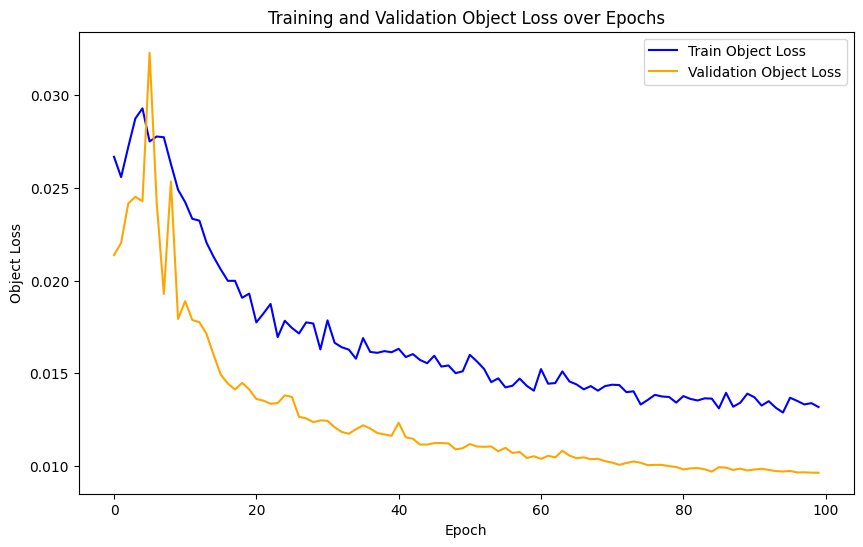

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# Find the latest experiment folder in Drive
DRIVE_RUNS_DIR = '/content/drive/MyDrive/pcb_yolov5_weights/runs'
exp_folders = glob.glob(os.path.join(DRIVE_RUNS_DIR, 'pcb_experiment*'))

if exp_folders:
    latest_exp = max(exp_folders, key=os.path.getmtime)
    results_path = os.path.join(latest_exp, 'results.csv')
    print(f'Using results from: {results_path}')
else:
    # Fallback to local runs if Drive not available
    local_folders = glob.glob('/content/yolov5/runs/my_experiment*')
    if local_folders:
        latest_exp = max(local_folders, key=os.path.getmtime)
        results_path = os.path.join(latest_exp, 'results.csv')
        print(f'Using local results from: {results_path}')
    else:
        raise FileNotFoundError('No experiment folders found!')

# Load results
df = pd.read_csv(results_path)
df.columns = df.columns.str.strip()

epochs = df['epoch']
train_obj_loss = df['train/obj_loss']
val_obj_loss = df['val/obj_loss']

# Plot Object Loss
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_obj_loss, label='Train Object Loss', color='blue')
plt.plot(epochs, val_obj_loss, label='Validation Object Loss', color='orange')

plt.title('Training and Validation Object Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Object Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Create test dataset

In [2]:
import os
import shutil

source_folder = '/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/rotation'
target_folder = '/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/test/images'

os.makedirs(target_folder, exist_ok=True)

subfolders = ['Spurious_copper_rotation', 'Mouse_bite_rotation', 'Open_circuit_rotation', 'Missing_hole_rotation']
for subfolder in subfolders:
    subfolder_path = os.path.join(source_folder, subfolder)
    if os.path.exists(subfolder_path):
        for filename in os.listdir(subfolder_path):
            if filename.endswith('.jpg'):
                source_filepath = os.path.join(subfolder_path, filename)
                target_filepath = os.path.join(target_folder, filename)
                shutil.copy2(source_filepath, target_filepath)

print("File copying complete!")


File copying complete!


In [3]:
from PIL import Image
import os

source_folder = '/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/test/images'
os.makedirs(source_folder, exist_ok=True)

# Resize images in-place
for filename in os.listdir(source_folder):
    if filename.endswith('.jpg'):
        filepath = os.path.join(source_folder, filename)
        img = Image.open(filepath)
        
        # Only resize if not already 640x640
        if img.size != (640, 640):
            img_resized = img.resize((640, 640))
            img_resized.save(filepath)
            print(f"Resized: {filename}")

print("File resizing complete!")


Resized: 01_missing_hole_02.jpg
Resized: 01_missing_hole_01.jpg
Resized: 01_missing_hole_14.jpg
Resized: 01_missing_hole_03.jpg
Resized: 01_missing_hole_11.jpg
Resized: 01_missing_hole_18.jpg
Resized: 01_missing_hole_12.jpg
Resized: 01_missing_hole_04.jpg
Resized: 01_missing_hole_20.jpg
Resized: 01_missing_hole_10.jpg
Resized: 01_missing_hole_13.jpg
Resized: 01_missing_hole_09.jpg
Resized: 01_missing_hole_06.jpg
Resized: 01_missing_hole_05.jpg
Resized: 01_missing_hole_17.jpg
Resized: 01_missing_hole_19.jpg
Resized: 01_missing_hole_16.jpg
Resized: 01_missing_hole_15.jpg
Resized: 01_missing_hole_08.jpg
Resized: 01_missing_hole_07.jpg
Resized: 04_missing_hole_09.jpg
Resized: 04_missing_hole_06.jpg
Resized: 04_missing_hole_03.jpg
Resized: 04_missing_hole_07.jpg
Resized: 04_missing_hole_10.jpg
Resized: 04_missing_hole_11.jpg
Resized: 04_missing_hole_02.jpg
Resized: 04_missing_hole_01.jpg
Resized: 04_missing_hole_04.jpg
Resized: 04_missing_hole_08.jpg
Resized: 04_missing_hole_05.jpg
Resized:

# Send JPGs from hripcb_dataset/PCB_DATASET/rotation to the previous model for testing

Feed into the previous model for training --> use best.pt

In [3]:
# If yolov5 repo exists:
#%cd /content/yolov5

# or if not, clone it first:
!git clone https://github.com/ultralytics/yolov5.git
%cd /content/yolov5
!pip install -qr requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 17851, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 17851 (delta 31), reused 15 (delta 8), pack-reused 17799 (from 3)
Receiving objects: 100% (17851/17851), 16.98 MiB | 17.98 MiB/s, done.
Resolving deltas: 100% (12161/12161), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 7.6 MB/s eta 0:00:00


In [4]:
import os
import glob

# Find best weights from Drive
DRIVE_RUNS_DIR = '/content/drive/MyDrive/pcb_yolov5_weights/runs'
exp_folders = glob.glob(os.path.join(DRIVE_RUNS_DIR, 'pcb_experiment*'))

if exp_folders:
    latest_exp = max(exp_folders, key=os.path.getmtime)
    BEST_WEIGHTS = os.path.join(latest_exp, 'weights', 'best.pt')
else:
    # Fallback to root Drive weights or local
    if os.path.exists('/content/drive/MyDrive/pcb_yolov5_weights/best.pt'):
        BEST_WEIGHTS = '/content/drive/MyDrive/pcb_yolov5_weights/best.pt'
    else:
        local_folders = glob.glob('/content/yolov5/runs/my_experiment*')
        if local_folders:
            latest_exp = max(local_folders, key=os.path.getmtime)
            BEST_WEIGHTS = os.path.join(latest_exp, 'weights', 'best.pt')
        else:
            raise FileNotFoundError('No trained weights found!')

print(f'Using weights: {BEST_WEIGHTS}')

# Detection output goes to Drive for persistence
DETECT_PROJECT = '/content/drive/MyDrive/pcb_yolov5_weights/detect'
TEST_IMAGES = '/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/test/images'

# Run detection
!python detect.py --weights $BEST_WEIGHTS --img-size 640 --conf 0.5 --source $TEST_IMAGES --save-txt --save-conf --project $DETECT_PROJECT --name exp --exist-ok

Using weights: /content/drive/MyDrive/pcb_yolov5_weights/runs/pcb_experiment/weights/best.pt
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
detect: weights=['/content/drive/MyDrive/pcb_yolov5_weights/runs/pcb_experiment/weights/best.pt'], source=/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.5, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=True, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=/content/drive/MyDrive/pcb_yolov5_weights/detect, name=exp, exist_ok=True, line_thickness=3, hide_labels=False, hide_co

###Random visual inspection from test dataset

Using detection results from: /content/drive/MyDrive/pcb_yolov5_weights/detect/exp


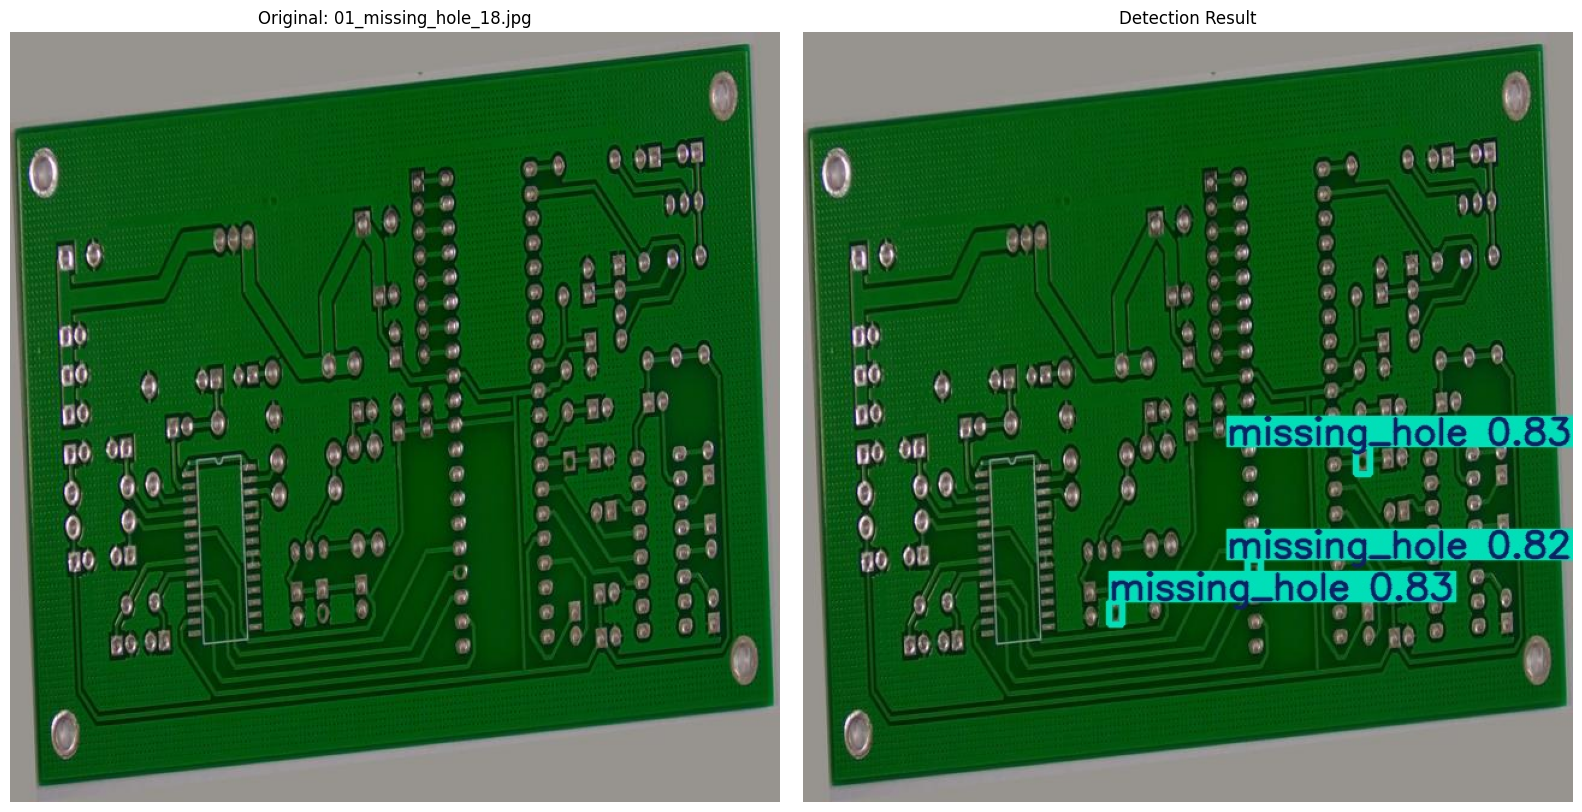

In [7]:
import os
import random
import glob
import matplotlib.pyplot as plt
from PIL import Image

# Paths - using Drive for persistence
original_folder = '/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/test/images'

# Find latest detection results in Drive
DRIVE_DETECT_DIR = '/content/drive/MyDrive/pcb_yolov5_weights/detect'
detect_folders = glob.glob(os.path.join(DRIVE_DETECT_DIR, 'exp*'))

if detect_folders:
    result_folder = max(detect_folders, key=os.path.getmtime)
    print(f'Using detection results from: {result_folder}')
else:
    # Fallback to local
    local_detect = glob.glob('/content/yolov5/runs/detect/exp*')
    if local_detect:
        result_folder = max(local_detect, key=os.path.getmtime)
        print(f'Using local detection results: {result_folder}')
    else:
        raise FileNotFoundError('No detection results found!')

# Get list of original test images
original_files = [f for f in os.listdir(original_folder) if f.endswith('.jpg')]

# Select a random file
selected_file = random.choice(original_files)
selected_original_filepath = os.path.join(original_folder, selected_file)

# Load images
original_img = Image.open(selected_original_filepath)
result_filepath = os.path.join(result_folder, selected_file)

if os.path.exists(result_filepath):
    result_img = Image.open(result_filepath)
    
    # Display side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    axes[0].imshow(original_img)
    axes[0].set_title(f'Original: {selected_file}')
    axes[0].axis('off')
    
    axes[1].imshow(result_img)
    axes[1].set_title(f'Detection Result')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print(f'Result image not found: {result_filepath}')
    print('Available result images:', os.listdir(result_folder)[:5])

---

## 🚨 Defect Severity Analysis & Solutions

### Overview
This section implements an industry-standard **4-level severity classification system**:

- 🔴 **CRITICAL** — Board must be scrapped immediately
- 🟠 **HIGH** — Significant defect, likely causes malfunction
- 🟡 **MODERATE** — May cause issues under stress or over time
- 🟢 **LOW** — Minor defect, unlikely to affect function

Each detected defect is analyzed for:
- ✅ Severity level (dynamically computed based on defect area, position, and confidence)
- ✅ Corrective solutions
- ✅ Criticality assessment
- ✅ Ship/repair decision
- ✅ Safety risk evaluation
- ✅ Board-level PASS/FAIL verdict

---

In [7]:
# ============================================================================
# DEFECT SEVERITY ANALYSIS - Database & Dynamic Severity Computation
# ============================================================================

import os
import glob
import random
from pathlib import Path
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# ── Class Names (must match the model's training order) ──
CLASS_NAMES = ['spurious_copper', 'mouse_bite', 'open_circuit', 'missing_hole', 'spur', 'short']

# ── Severity Colour & Icon Mapping ──
SEVERITY_COLORS = {
    'CRITICAL': '#F44336',  # Red
    'HIGH':     '#FF9800',  # Orange
    'MODERATE': '#FFC107',  # Yellow
    'LOW':      '#4CAF50',  # Green
}

SEVERITY_ICONS = {
    'CRITICAL': '🔴',
    'HIGH':     '🟠',
    'MODERATE': '🟡',
    'LOW':      '🟢',
}

SEVERITY_ORDER = ['LOW', 'MODERATE', 'HIGH', 'CRITICAL']

# ── Comprehensive Defect Information Database ──
DEFECT_INFO = {
    'missing_hole': {
        'severity': 'HIGH',
        'icon': '🟠',
        'color': '#FF9800',
        'description': 'Prevents component mounting; blocks through-hole component installation',
        'solutions': [
            'Re-drilling: Use CNC drilling machine at correct coordinates',
            'Manual drilling: Use precision drill press with appropriate bit size',
            'Wire alternative: Use surface-mount alternative if possible',
            'Prevention: Verify drilling program (G-code) and ensure proper machine calibration'
        ],
        'criticality': 'High for functional holes (vias, component leads); Moderate for mounting holes',
        'decision': '⚠️ REPAIR REQUIRED',
        'safety': 'Low risk',
        'repairability': 'Easy to Moderate',
        'impact': 'Board may be non-functional if holes are for critical vias or components'
    },
    'mouse_bite': {
        'severity': 'LOW',
        'icon': '🟢',
        'color': '#4CAF50',
        'description': 'Small indentations or bites on the edges of the PCB',
        'solutions': [
            'Manual filing/sanding: Smooth edges with fine-grit sandpaper or files',
            'Precision routing: Use a precision router to clean up the edge',
            'Deburring: Use deburring tool for small bites',
            'Prevention: Optimize V-scoring or routing parameters during panelization'
        ],
        'criticality': 'Low for internal boards; Moderate for edge connectors',
        'decision': '✓ May Ship As-Is (check tolerance specifications)',
        'safety': 'Low risk (possible sharp edges - handling hazard)',
        'repairability': 'Easy',
        'impact': 'Primarily cosmetic; may affect board fit in enclosure'
    },
    'open_circuit': {
        'severity': 'CRITICAL',
        'icon': '🔴',
        'color': '#F44336',
        'description': 'Circuit paths that are broken or disconnected - complete loss of electrical connectivity',
        'solutions': [
            'Solder bridging: Apply solder to bridge the gap in the broken trace',
            'Wire jumpers: Solder thin wire (jumper wire) across the break',
            'Conductive ink/epoxy: Use conductive paint or epoxy for small breaks',
            'Copper tape: Apply copper tape over the break and solder connections',
            '⚠️ MANDATORY: 100% electrical continuity testing required after repair'
        ],
        'criticality': 'VERY HIGH - Circuit cannot function properly; complete path failure',
        'decision': '❌ NEVER SHIP - Must Repair or Scrap',
        'safety': 'Medium risk (can cause overcurrent in alternate paths)',
        'repairability': 'Moderate (requires skilled repair)',
        'impact': 'Device failure, malfunction, or total non-functionality'
    },
    'short': {
        'severity': 'CRITICAL',
        'icon': '🔴',
        'color': '#F44336',
        'description': 'Unintended electrical connection between circuit paths causing malfunction or damage',
        'solutions': [
            'Cutting/scraping: Use X-ACTO knife to remove unwanted copper bridge',
            'Chemical etching: Apply etchant (ferric chloride) locally with cotton swab',
            'Laser ablation: Use laser to precisely remove the short (production environment)',
            'Precision grinding: Use Dremel with fine bit for larger shorts',
            '⚠️ MANDATORY: Short circuit testing and resistance measurements required'
        ],
        'criticality': 'VERY HIGH - Can damage components, cause fire, or destroy power supply',
        'decision': '❌ NEVER SHIP - Must Fix Immediately',
        'safety': 'HIGH risk (component damage, overcurrent, fire hazard)',
        'repairability': 'Easy to Moderate',
        'impact': 'Component burnout, power supply failure, fire risk'
    },
    'spurious_copper': {
        'severity': 'MODERATE',
        'icon': '🟡',
        'color': '#FFC107',
        'description': 'Unwanted copper deposits or residues on the PCB surface',
        'solutions': [
            'Mechanical removal: Scrape off excess copper with blade or precision tools',
            'Chemical spot etching: Apply ferric chloride locally',
            'Ultrasonic cleaning: Remove loose copper particles',
            'Prevention: Improve cleaning process after etching'
        ],
        'criticality': 'High if near signal traces (potential shorting); Moderate if isolated',
        'decision': '⚠️ REPAIR REQUIRED',
        'safety': 'Medium risk (potential shorting)',
        'repairability': 'Easy',
        'impact': 'May create shorts or signal integrity issues over time'
    },
    'spur': {
        'severity': 'LOW',
        'icon': '🟢',
        'color': '#4CAF50',
        'description': 'Small protrusions or extensions from traces that extend beyond intended boundaries',
        'solutions': [
            'Trimming: Cut off spurs with precision cutters',
            'Grinding: Use fine grinding tool to smooth protrusion',
            'Deburring: Use deburring tool to remove sharp edges',
            'Prevention: Optimize etching parameters'
        ],
        'criticality': 'Low if isolated; High if close to other conductors',
        'decision': '✓ Usually Acceptable (check if isolated)',
        'safety': 'Low to Medium',
        'repairability': 'Easy',
        'impact': 'May cause shorts if close to adjacent traces'
    }
}

# ── Base Severity & Reasons for Dynamic Computation ──
BASE_SEVERITY = {name: info['severity'] for name, info in DEFECT_INFO.items()}

BASE_REASON = {
    'missing_hole':     'Hole absent from expected location; component mounting compromised.',
    'mouse_bite':       'Edge irregularity from depanelization; mostly cosmetic.',
    'open_circuit':     'Broken trace detected; electrical path is interrupted.',
    'short':            'Unintended copper bridge creating unwanted connection.',
    'spurious_copper':  'Excess copper residue on board surface.',
    'spur':             'Trace protrusion extending beyond design boundary.',
}


def escalate(severity):
    """Move severity one level up."""
    idx = SEVERITY_ORDER.index(severity)
    return SEVERITY_ORDER[min(idx + 1, len(SEVERITY_ORDER) - 1)]

def deescalate(severity):
    """Move severity one level down."""
    idx = SEVERITY_ORDER.index(severity)
    return SEVERITY_ORDER[max(idx - 1, 0)]


def compute_severity(class_name, box, img_w, img_h, confidence):
    """
    Dynamically compute severity based on:
      - Defect type (base severity)
      - Defect area relative to board size
      - Position on board (edge vs center)
      - Detection confidence
    Returns: (severity_level, reason_string)
    """
    x1, y1, x2, y2 = box
    area_fraction = abs((x2 - x1) * (y2 - y1)) / (img_w * img_h)

    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    near_edge = (cx < img_w * 0.1 or cx > img_w * 0.9 or
                 cy < img_h * 0.1 or cy > img_h * 0.9)

    severity  = BASE_SEVERITY[class_name]
    modifiers = []

    # Area-based adjustment
    if area_fraction > 0.05:
        severity = escalate(severity)
        modifiers.append(f'large defect area ({area_fraction*100:.1f}% of board) amplifies impact')
    elif area_fraction < 0.005:
        severity = deescalate(severity)
        modifiers.append(f'small defect area ({area_fraction*100:.2f}% of board) limits impact')

    # Position-based adjustment
    if near_edge:
        severity = deescalate(severity)
        modifiers.append('located near the board edge, away from critical central traces')
    elif BASE_SEVERITY[class_name] in ('CRITICAL', 'HIGH'):
        modifiers.append('positioned in the central PCB region where trace density is highest')

    # Confidence-based adjustment
    if confidence < 0.4:
        severity = deescalate(severity)
        modifiers.append(f'low detection confidence ({confidence:.0%}) — defect boundary uncertain')
    elif confidence > 0.85:
        modifiers.append(f'high detection confidence ({confidence:.0%}) — defect clearly identified')

    reason = BASE_REASON[class_name]
    if modifiers:
        reason += ' Additionally, ' + '; '.join(modifiers) + '.'

    return severity, reason


# ── Parse YOLOv5 Labels ──
def parse_yolo_labels(label_path, img_w, img_h):
    """Parse YOLO detection label file into structured detections."""
    detections = []
    if not os.path.exists(label_path):
        return detections
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            xc, yc, w, h = map(float, parts[1:5])
            conf = float(parts[5]) if len(parts) > 5 else 1.0
            x1 = int((xc - w / 2) * img_w)
            y1 = int((yc - h / 2) * img_h)
            x2 = int((xc + w / 2) * img_w)
            y2 = int((yc + h / 2) * img_h)
            detections.append({
                'class_id':   cls_id,
                'class_name': CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else f'class_{cls_id}',
                'box':        (x1, y1, x2, y2),
                'confidence': conf,
            })
    return detections


# ── Annotate Image with Severity-Coloured Bounding Boxes ──
def annotate_image(img_pil, detections, img_w, img_h, display_w=500):
    """Draw bounding boxes with severity colours on a resized image."""
    ratio = img_pil.height / img_pil.width
    img_resized = img_pil.resize((display_w, int(display_w * ratio)))

    scale_x = display_w / img_w
    scale_y = int(display_w * ratio) / img_h

    draw = ImageDraw.Draw(img_resized)
    for det in detections:
        color = SEVERITY_COLORS[det['severity']]
        x1, y1, x2, y2 = det['box']
        sx1, sy1 = int(x1 * scale_x), int(y1 * scale_y)
        sx2, sy2 = int(x2 * scale_x), int(y2 * scale_y)

        # Draw bounding box
        draw.rectangle([sx1, sy1, sx2, sy2], outline=color, width=2)

        # Only draw the severity box; the original detection image already contains the class label.

    return img_resized


print('✅ Defect database loaded & severity functions defined')
print(f'   {len(DEFECT_INFO)} defect types configured')
print(f'   Severity levels: {" → ".join(SEVERITY_ORDER)}')


✅ Defect database loaded & severity functions defined
   6 defect types configured
   Severity levels: LOW → MODERATE → HIGH → CRITICAL


### 🔍 Run Severity Analysis on Test Detection Results

This cell processes all detected images, annotates them with **severity-coloured bounding boxes**, and prints:
1. Annotated image with colour-coded defect boxes
2. Board-level **PASS/FAIL** verdict
3. Per-defect breakdown: severity, confidence, detailed reason
4. Corrective solutions and repair decisions


In [8]:
# ============================================================================
# RUN SEVERITY ANALYSIS ON DETECTION RESULTS
# ============================================================================

# Paths - point to the detection output directory
DRIVE_DETECT_DIR = '/content/drive/MyDrive/pcb_yolov5_weights/detect'
detect_folders = glob.glob(os.path.join(DRIVE_DETECT_DIR, 'exp*'))

if detect_folders:
    detect_dir = max(detect_folders, key=os.path.getmtime)
else:
    detect_dir = os.path.join(DRIVE_DETECT_DIR, 'exp')

label_dir = os.path.join(detect_dir, 'labels')

print(f'📁 Detection directory: {detect_dir}')
print(f'📁 Labels directory:    {label_dir}')

# Gather all detected images
all_images = sorted(
    glob.glob(f'{detect_dir}/*.jpg') +
    glob.glob(f'{detect_dir}/*.png')
)

print(f'📊 Found {len(all_images)} detected images')

if not all_images:
    print('⚠️ No detected images found. Make sure detection was run with --save-txt --save-conf')
else:
    # Sample 10 random images for display
    random.seed(42)
    sample_images = random.sample(all_images, min(10, len(all_images)))

    SAVE_DIR = os.path.join(detect_dir, 'analysis_images')
    os.makedirs(SAVE_DIR, exist_ok=True)

    SEV_ICON = {'CRITICAL': '🔴', 'HIGH': '🟠', 'MODERATE': '🟡', 'LOW': '🟢'}

    def save_analysis_image(img_name, annotated_img, raw_dets, total_defects, verdict, verdict_reason, save_path):
        verdict_icon = '❌' if verdict == 'FAIL' else '✅'
        analysis_lines = [
            f'Defects Found  : {total_defects}',
            f'Board Verdict  : {verdict_icon} {verdict}  ({verdict_reason})',
            ''
        ]

        if not raw_dets:
            analysis_lines += ['No defects detected — board is clean.', '']
        else:
            analysis_lines += ['Per-defect breakdown:', '']
            for i, d in enumerate(raw_dets, 1):
                icon = SEV_ICON[d['severity']]
                analysis_lines.append(f'Defect {i}')
                analysis_lines.append(f'  Name        : {d["class_name"]}')
                analysis_lines.append(f'  Severity    : {icon}  {d["severity"]}')
                analysis_lines.append(f'  Confidence  : {d["confidence"]:.0%}')
                analysis_lines.append(f'  Reason      : {d["reason"]}')

                if d['class_name'] in DEFECT_INFO:
                    info = DEFECT_INFO[d['class_name']]
                    analysis_lines.append(f'  Decision    : {info["decision"]}')
                    analysis_lines.append('  Solutions   :')
                    for sol in info['solutions']:
                        analysis_lines.append(f'    • {sol}')
                analysis_lines.append('')

        analysis_lines += [
            'Bounding Box Colour Legend',
            '🔴 CRITICAL — board must be scrapped immediately',
            '🟠 HIGH     — significant defect, likely causes malfunction',
            '🟡 MODERATE — may cause issues under stress or over time',
            '🟢 LOW      — minor defect, unlikely to affect function'
        ]

        fig_h = max(10, 6 + 0.35 * len(analysis_lines))
        fig = plt.figure(figsize=(14, fig_h))
        gs = fig.add_gridspec(2, 1, height_ratios=[3, 2])

        ax_img = fig.add_subplot(gs[0])
        ax_img.imshow(annotated_img)
        ax_img.axis('off')
        ax_img.set_title(f'{img_name} - {verdict_icon} {verdict}', fontsize=14, fontweight='bold', pad=12)

        ax_text = fig.add_subplot(gs[1])
        ax_text.axis('off')
        ax_text.text(
            0.01, 0.99, '\n'.join(analysis_lines),
            transform=ax_text.transAxes,
            fontsize=8.5,
            va='top',
            family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.25)
        )

        fig.tight_layout()
        fig.savefig(save_path, dpi=180, bbox_inches='tight', facecolor='white')
        plt.close(fig)

    for idx, img_path in enumerate(sample_images, 1):
        img_name   = Path(img_path).stem
        label_path = os.path.join(label_dir, img_name + '.txt')

        img_pil      = Image.open(img_path).convert('RGB')
        img_w, img_h = img_pil.size

        # Parse & score every detection
        raw_dets = parse_yolo_labels(label_path, img_w, img_h)
        for det in raw_dets:
            det['severity'], det['reason'] = compute_severity(
                det['class_name'], det['box'], img_w, img_h, det['confidence']
            )

        # ── Board-level Verdict ──
        has_critical  = any(d['severity'] == 'CRITICAL' for d in raw_dets)
        high_count    = sum(1 for d in raw_dets if d['severity'] == 'HIGH')
        total_defects = len(raw_dets)

        if has_critical or high_count >= 3 or total_defects >= 5:
            verdict = 'FAIL'
            verdict_reason = (
                'Contains CRITICAL defect(s).'              if has_critical  else
                f'{high_count} HIGH severity defects found.' if high_count >= 3 else
                f'Too many defects ({total_defects}) on board.'
            )
        else:
            verdict = 'PASS'
            verdict_reason = f'{total_defects} defect(s) found, none critical.'

        # ── 1. Build annotated image for saving ──
        annotated = annotate_image(img_pil, raw_dets, img_w, img_h, display_w=500)

        # ── 2. Board summary ──
        print(f'\n  Defects Found  : {total_defects}')
        verdict_icon = '❌' if verdict == 'FAIL' else '✅'
        print(f'  Board Verdict  : {verdict_icon} {verdict}  ({verdict_reason})\n')

        save_path = os.path.join(SAVE_DIR, f'{img_name}_analysis.png')
        save_analysis_image(img_name, annotated, raw_dets, total_defects, verdict, verdict_reason, save_path)
        print(f'  💾 Saved analysis image to: {save_path}')

        if not raw_dets:
            print('  No defects detected — board is clean.\n')
            continue

        # ── 3. Per-defect breakdown ──
        for i, d in enumerate(raw_dets, 1):
            icon = SEV_ICON[d['severity']]
            print(f'  Defect {i}')
            print(f'    Name        : {d["class_name"]}')
            print(f'    Severity    : {icon}  {d["severity"]}')
            print(f'    Confidence  : {d["confidence"]:.0%}')
            print(f'    Reason      : {d["reason"]}')

            # Show solutions from database
            if d['class_name'] in DEFECT_INFO:
                info = DEFECT_INFO[d['class_name']]
                print(f'    Decision    : {info["decision"]}')
                print(f'    Solutions   :')
                for sol in info['solutions']:
                    print(f'      • {sol}')
            print()

        print('─' * 60)

    # ── Legend ──
    print()
    print('=' * 50)
    print('  Bounding Box Colour Legend')
    print('=' * 50)
    print('  🔴 CRITICAL — board must be scrapped immediately')
    print('  🟠 HIGH     — significant defect, likely causes malfunction')
    print('  🟡 MODERATE — may cause issues under stress or over time')
    print('  🟢 LOW      — minor defect, unlikely to affect function')


📁 Detection directory: /content/drive/MyDrive/pcb_yolov5_weights/detect/exp
📁 Labels directory:    /content/drive/MyDrive/pcb_yolov5_weights/detect/exp/labels
📊 Found 462 detected images

  Defects Found  : 5
  Board Verdict  : ❌ FAIL  (Too many defects (5) on board.)



/tmp/ipykernel_9964/2265352076.py:95: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_9964/2265352076.py:95: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  fig.tight_layout()
/tmp/ipykernel_9964/2265352076.py:95: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans Mono.
  fig.tight_layout()
/tmp/ipykernel_9964/2265352076.py:95: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  fig.tight_layout()
/tmp/ipykernel_9964/2265352076.py:95: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans Mono.
  fig.tight_layout()
/tmp/ipykernel_9964/2265352076.py:95: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans Mono.
  fig.tight_layout()
/tmp/ipykernel_9964/2265352076.py:95: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans Mono.

  💾 Saved analysis image to: /content/drive/MyDrive/pcb_yolov5_weights/detect/exp/analysis_images/09_missing_hole_08_analysis.png
  Defect 1
    Name        : missing_hole
    Severity    : 🟡  MODERATE
    Confidence  : 76%
    Reason      : Hole absent from expected location; component mounting compromised. Additionally, small defect area (0.05% of board) limits impact; positioned in the central PCB region where trace density is highest.
    Decision    : ⚠️ REPAIR REQUIRED
    Solutions   :
      • Re-drilling: Use CNC drilling machine at correct coordinates
      • Manual drilling: Use precision drill press with appropriate bit size
      • Wire alternative: Use surface-mount alternative if possible
      • Prevention: Verify drilling program (G-code) and ensure proper machine calibration

  Defect 2
    Name        : missing_hole
    Severity    : 🟢  LOW
    Confidence  : 81%
    Reason      : Hole absent from expected location; component mounting compromised. Additionally, small d

/tmp/ipykernel_9964/2265352076.py:95: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_9964/2265352076.py:95: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.tight_layout()
/tmp/ipykernel_9964/2265352076.py:96: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=180, bbox_inches='tight', facecolor='white')
/tmp/ipykernel_9964/2265352076.py:96: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.savefig(save_path, dpi=180, bbox_inches='tight', facecolor='white')


  💾 Saved analysis image to: /content/drive/MyDrive/pcb_yolov5_weights/detect/exp/analysis_images/01_missing_hole_13_analysis.png
  Defect 1
    Name        : missing_hole
    Severity    : 🟡  MODERATE
    Confidence  : 80%
    Reason      : Hole absent from expected location; component mounting compromised. Additionally, small defect area (0.05% of board) limits impact; positioned in the central PCB region where trace density is highest.
    Decision    : ⚠️ REPAIR REQUIRED
    Solutions   :
      • Re-drilling: Use CNC drilling machine at correct coordinates
      • Manual drilling: Use precision drill press with appropriate bit size
      • Wire alternative: Use surface-mount alternative if possible
      • Prevention: Verify drilling program (G-code) and ensure proper machine calibration

  Defect 2
    Name        : missing_hole
    Severity    : 🟡  MODERATE
    Confidence  : 83%
    Reason      : Hole absent from expected location; component mounting compromised. Additionally, sm

### 📊 Full Board Severity Summary (All Test Images)

Aggregate severity analysis across **all** test detection results — generates a summary table and severity distribution chart.

  📊 BOARD-LEVEL SEVERITY SUMMARY
  Total boards analyzed : 462
  ✅ PASS               : 174 (37.7%)
  ❌ FAIL               : 288 (62.3%)

  Defect Severity Distribution:
    🔴 CRITICAL  : 0 defects
    🟠 HIGH      : 410 defects
    🟡 MODERATE  : 496 defects
    🟢 LOW       : 1033 defects

  Per-Defect-Type Breakdown:
    spurious_copper      ( 466 total) → LOW: 466
    mouse_bite           ( 443 total) → LOW: 443
    open_circuit         ( 425 total) → HIGH: 409, MODERATE: 16
    missing_hole         ( 504 total) → MODERATE: 480, LOW: 24
    spur                 ( 100 total) → LOW: 100
    short                (   1 total) → HIGH: 1


/tmp/ipykernel_711/3833956619.py:113: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


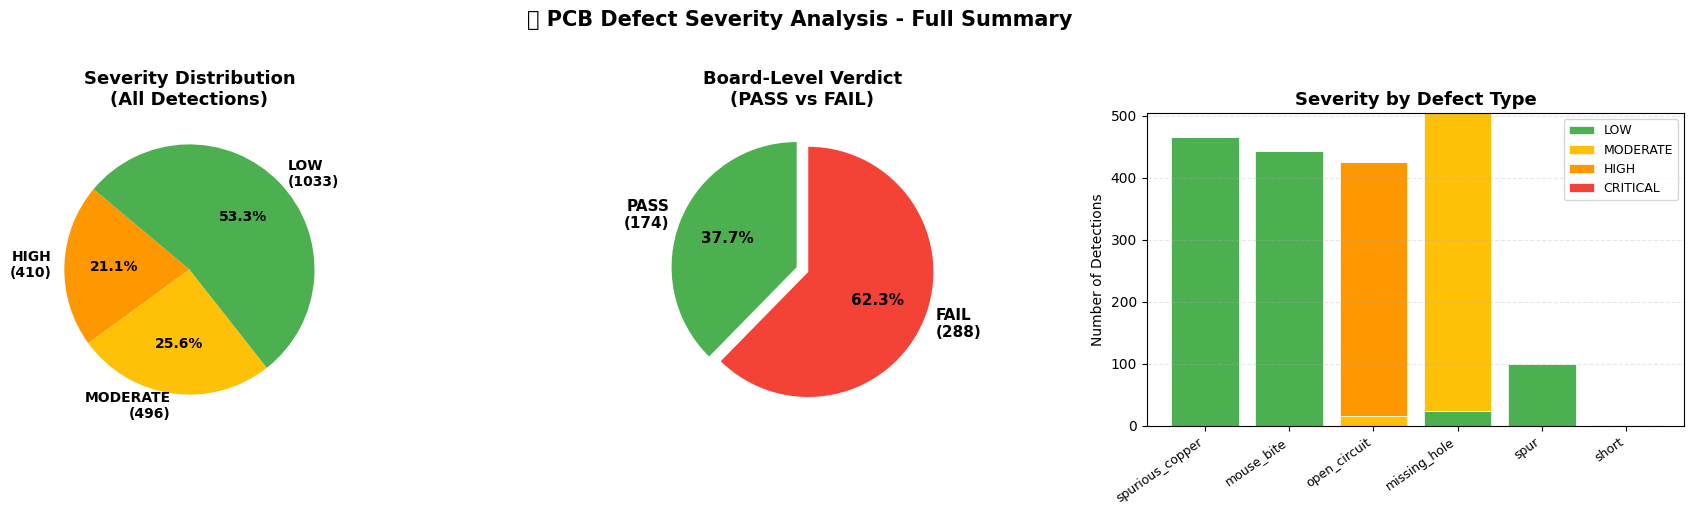

In [4]:
# ============================================================================
# AGGREGATE SEVERITY SUMMARY ACROSS ALL TEST IMAGES
# ============================================================================

from collections import Counter, defaultdict
import numpy as np

board_verdicts  = []  # (img_name, verdict, total_defects, max_severity)
severity_counts = Counter()  # Global severity distribution
defect_type_severity = defaultdict(list)  # defect_name -> [severities]

for img_path in all_images:
    img_name   = Path(img_path).stem
    label_path = os.path.join(label_dir, img_name + '.txt')

    img_pil      = Image.open(img_path).convert('RGB')
    img_w, img_h = img_pil.size

    raw_dets = parse_yolo_labels(label_path, img_w, img_h)
    for det in raw_dets:
        det['severity'], det['reason'] = compute_severity(
            det['class_name'], det['box'], img_w, img_h, det['confidence']
        )
        severity_counts[det['severity']] += 1
        defect_type_severity[det['class_name']].append(det['severity'])

    # Board verdict
    has_critical  = any(d['severity'] == 'CRITICAL' for d in raw_dets)
    high_count    = sum(1 for d in raw_dets if d['severity'] == 'HIGH')
    total_defects = len(raw_dets)

    if has_critical or high_count >= 3 or total_defects >= 5:
        verdict = 'FAIL'
    else:
        verdict = 'PASS'

    max_sev = 'LOW'
    for d in raw_dets:
        if SEVERITY_ORDER.index(d['severity']) > SEVERITY_ORDER.index(max_sev):
            max_sev = d['severity']

    board_verdicts.append((img_name, verdict, total_defects, max_sev))

# ── Print Summary ──
pass_count = sum(1 for _, v, _, _ in board_verdicts if v == 'PASS')
fail_count = sum(1 for _, v, _, _ in board_verdicts if v == 'FAIL')

print('=' * 60)
print('  📊 BOARD-LEVEL SEVERITY SUMMARY')
print('=' * 60)
print(f'  Total boards analyzed : {len(board_verdicts)}')
print(f'  ✅ PASS               : {pass_count} ({pass_count/len(board_verdicts)*100:.1f}%)')
print(f'  ❌ FAIL               : {fail_count} ({fail_count/len(board_verdicts)*100:.1f}%)')
print()
print('  Defect Severity Distribution:')
for sev in SEVERITY_ORDER[::-1]:  # CRITICAL first
    icon = SEVERITY_ICONS[sev]
    count = severity_counts.get(sev, 0)
    print(f'    {icon} {sev:10s}: {count} defects')

print()
print('  Per-Defect-Type Breakdown:')
for defect_name in CLASS_NAMES:
    if defect_name in defect_type_severity:
        sevs = defect_type_severity[defect_name]
        sev_dist = Counter(sevs)
        parts = ', '.join(f'{s}: {c}' for s, c in sorted(sev_dist.items(), key=lambda x: SEVERITY_ORDER.index(x[0]), reverse=True))
        print(f'    {defect_name:20s} ({len(sevs):4d} total) → {parts}')
print('=' * 60)

# ── Visualization ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Severity distribution pie chart
ax = axes[0]
sev_labels = [s for s in SEVERITY_ORDER[::-1] if severity_counts.get(s, 0) > 0]
sev_values = [severity_counts[s] for s in sev_labels]
sev_colors = [SEVERITY_COLORS[s] for s in sev_labels]
ax.pie(sev_values, labels=[f'{s}\n({v})' for s, v in zip(sev_labels, sev_values)],
       colors=sev_colors, autopct='%1.1f%%', startangle=140,
       textprops={'fontsize': 10, 'fontweight': 'bold'})
ax.set_title('Severity Distribution\n(All Detections)', fontsize=13, fontweight='bold')

# 2. Board verdict pie chart
ax = axes[1]
ax.pie([pass_count, fail_count],
       labels=[f'PASS\n({pass_count})', f'FAIL\n({fail_count})'],
       colors=['#4CAF50', '#F44336'], autopct='%1.1f%%', startangle=90,
       textprops={'fontsize': 11, 'fontweight': 'bold'},
       explode=(0.05, 0.05))
ax.set_title('Board-Level Verdict\n(PASS vs FAIL)', fontsize=13, fontweight='bold')

# 3. Per-defect severity stacked bar chart
ax = axes[2]
defect_names = [d for d in CLASS_NAMES if d in defect_type_severity]
x = np.arange(len(defect_names))
bottom = np.zeros(len(defect_names))

for sev in SEVERITY_ORDER:
    values = [Counter(defect_type_severity[d]).get(sev, 0) for d in defect_names]
    ax.bar(x, values, bottom=bottom, label=sev, color=SEVERITY_COLORS[sev],
           edgecolor='white', linewidth=0.5)
    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(defect_names, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Number of Detections')
ax.set_title('Severity by Defect Type', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('🚨 PCB Defect Severity Analysis - Full Summary', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
